# 🎬 CineMetric — Movie Rating Prediction

A machine-learning pipeline that predicts movie ratings using a **Random Forest Regressor**.

**Tech stack:** Pandas · NumPy · Scikit-learn · Seaborn · Matplotlib

In [1]:
# ── Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13
})
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 1. Data Loading & Exploration

In [2]:
# ── Load the dataset ─────────────────────────────────────────────────
df = pd.read_csv('movies_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (200, 6)

Columns: ['title', 'genres', 'synopsis', 'rating', 'actors', 'directors']


,title,genres,synopsis,rating,actors,directors
0,Your Heart Will Be Broken,"Romance,Drama",High school student Polina is saved from bully...,6.000,"Veronika Zhuravleva,Daniel Vegas,Alya Mayer",Mikhail Vaynberg
1,Peaky Blinders: The Immortal Man,"Crime,Drama",After his estranged son gets embroiled in a Na...,7.363,"Cillian Murphy,Barry Keoghan,Rebecca Ferguson",Tom Harper
2,Avatar: Fire and Ash,"Science Fiction,Adventure,Fantasy",In the wake of the devastating war against the...,7.260,"Sam Worthington,Zoe Saldaña,Sigourney Weaver",James Cameron
3,Project Hail Mary,"Science Fiction,Adventure",Science teacher Ryland Grace wakes up on a spa...,8.200,"Ryan Gosling,James Ortiz,Sandra Hüller","Phil Lord,Christopher Miller"
4,Shelter,"Action,Crime,Thriller",A man living in self-imposed exile on a remote...,6.740,"Jason Statham,Bodhi Rae Breathnach,Michael Sha...",Ric Roman Waugh


In [3]:
# ── Data types & missing values ──────────────────────────────────────
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Basic Statistics ===")
df.describe()

=== Data Types ===
title            str
genres           str
synopsis         str
rating       float64
actors           str
directors        str
dtype: object

=== Missing Values ===
title        0
genres       1
synopsis     1
rating       0
actors       4
directors    3
dtype: int64

=== Basic Statistics ===


,rating
count,200.000000
mean,6.101165
std,2.202701
min,0.000000
25%,5.594500
50%,6.700500
75%,7.500000
max,10.000000


## 2. Data Cleaning

Clean the dataset by:
- Removing rows with placeholder ratings (0.0)
- Handling missing values in `genres`, `directors`, and `actors`
- Stripping whitespace from text fields

In [4]:
# ── Data Cleaning ────────────────────────────────────────────────────
print(f"Original dataset size: {len(df)} rows")

# Drop rows where rating is 0.0 (placeholder / missing)
df = df[df['rating'] > 0].copy()
print(f"After removing 0.0 ratings: {len(df)} rows")

# Drop rows with missing genres or directors (essential features)
df = df.dropna(subset=['genres', 'directors']).copy()
print(f"After removing missing genres/directors: {len(df)} rows")

# Fill missing actors with 'Unknown'
df['actors'] = df['actors'].fillna('Unknown')

# Strip whitespace from text columns
for col in ['genres', 'directors', 'actors']:
    df[col] = df[col].str.strip()

# Drop duplicates by title (keep first)
df = df.drop_duplicates(subset='title', keep='first').copy()
print(f"After removing duplicates: {len(df)} rows")

print(f"\n✅ Cleaned dataset: {df.shape[0]} movies, {df.shape[1]} columns")
print(f"Rating range: {df['rating'].min():.1f} – {df['rating'].max():.1f}")
df.head()

Original dataset size: 200 rows
After removing 0.0 ratings: 183 rows
After removing missing genres/directors: 180 rows
After removing duplicates: 178 rows

✅ Cleaned dataset: 178 movies, 6 columns
Rating range: 3.4 – 10.0


,title,genres,synopsis,rating,actors,directors
0,Your Heart Will Be Broken,"Romance,Drama",High school student Polina is saved from bully...,6.000,"Veronika Zhuravleva,Daniel Vegas,Alya Mayer",Mikhail Vaynberg
1,Peaky Blinders: The Immortal Man,"Crime,Drama",After his estranged son gets embroiled in a Na...,7.363,"Cillian Murphy,Barry Keoghan,Rebecca Ferguson",Tom Harper
2,Avatar: Fire and Ash,"Science Fiction,Adventure,Fantasy",In the wake of the devastating war against the...,7.260,"Sam Worthington,Zoe Saldaña,Sigourney Weaver",James Cameron
3,Project Hail Mary,"Science Fiction,Adventure",Science teacher Ryland Grace wakes up on a spa...,8.200,"Ryan Gosling,James Ortiz,Sandra Hüller","Phil Lord,Christopher Miller"
4,Shelter,"Action,Crime,Thriller",A man living in self-imposed exile on a remote...,6.740,"Jason Statham,Bodhi Rae Breathnach,Michael Sha...",Ric Roman Waugh


## 3. Feature Engineering

- **Genres**: Multi-label binarization (one-hot encoding) since movies can belong to multiple genres
- **Directors**: Label encoding
- **Lead Actor**: Extract the first listed actor and label-encode

In [5]:
# ── Genre: Multi-Label Binarization ─────────────────────────────────
# Split genres into lists
df['genre_list'] = df['genres'].apply(lambda x: [g.strip() for g in x.split(',')])

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['genre_list']),
    columns=[f"genre_{g}" for g in mlb.classes_],
    index=df.index
)

print(f"Number of unique genres: {len(mlb.classes_)}")
print(f"Genres: {list(mlb.classes_)}")
genre_encoded.head()

Number of unique genres: 19
Genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [6]:
# ── Director: Label Encoding ────────────────────────────────────────
# Use the primary director (first listed)
df['primary_director'] = df['directors'].apply(lambda x: x.split(',')[0].strip())

le_director = LabelEncoder()
df['director_encoded'] = le_director.fit_transform(df['primary_director'])

print(f"Number of unique directors: {df['primary_director'].nunique()}")
print(f"\nTop 10 directors by movie count:")
print(df['primary_director'].value_counts().head(10))

Number of unique directors: 161

Top 10 directors by movie count:
primary_director
Christopher Nolan    5
James Cameron        4
Ric Roman Waugh      3
Jon Watts            3
Sam Raimi            2
Aditya Dhar          2
Frank Darabont       2
Peter Jackson        2
Joseph Kosinski      2
Denis Villeneuve     2
Name: count, dtype: int64


In [7]:
# ── Lead Actor: Label Encoding ──────────────────────────────────────
df['lead_actor'] = df['actors'].apply(lambda x: x.split(',')[0].strip())

le_actor = LabelEncoder()
df['actor_encoded'] = le_actor.fit_transform(df['lead_actor'])

print(f"Number of unique lead actors: {df['lead_actor'].nunique()}")
print(f"\nTop 10 lead actors by movie count:")
print(df['lead_actor'].value_counts().head(10))

Number of unique lead actors: 161

Top 10 lead actors by movie count:
lead_actor
Robert Downey Jr.    4
Sam Worthington      3
Tom Holland          3
Leonardo DiCaprio    3
Timothée Chalamet    3
Cillian Murphy       2
Ranveer Singh        2
Chris Pratt          2
Jeremy Irvine        2
Glen Powell          2
Name: count, dtype: int64


In [8]:
# ── Assemble Feature Matrix ─────────────────────────────────────────
# Combine genre one-hot columns + encoded director + encoded actor
feature_cols = list(genre_encoded.columns) + ['director_encoded', 'actor_encoded']

X = pd.concat([genre_encoded, df[['director_encoded', 'actor_encoded']]], axis=1)
y = df['rating']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Feature matrix shape: (178, 21)
Target variable shape: (178,)

Features (21):
   1. genre_Action
   2. genre_Adventure
   3. genre_Animation
   4. genre_Comedy
   5. genre_Crime
   6. genre_Documentary
   7. genre_Drama
   8. genre_Family
   9. genre_Fantasy
  10. genre_History
  11. genre_Horror
  12. genre_Music
  13. genre_Mystery
  14. genre_Romance
  15. genre_Science Fiction
  16. genre_TV Movie
  17. genre_Thriller
  18. genre_War
  19. genre_Western
  20. director_encoded
  21. actor_encoded


## 4. Model Building

Split the data 80/20 and train a **Random Forest Regressor** with 100 estimators.

In [9]:
# ── Train/Test Split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 142 samples
Test set:     36 samples


In [10]:
# ── Train Random Forest Regressor ───────────────────────────────────
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("✅ Model trained successfully!")

# Predictions
y_pred = model.predict(X_test)

✅ Model trained successfully!


## 5. Model Evaluation

In [11]:
# ── Evaluation Metrics ──────────────────────────────────────────────
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=" * 50)
print("       MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Mean Squared Error (MSE) : {mse:.4f}")
print(f"  Root MSE (RMSE)          : {np.sqrt(mse):.4f}")
print(f"  R² Score                 : {r2:.4f}")
print("=" * 50)

if r2 > 0.5:
    print("\n📊 The model explains a decent portion of variance.")
elif r2 > 0:
    print("\n📊 The model has some predictive power, but limited by dataset size.")
else:
    print("\n📊 The model struggles — likely due to the small dataset and high cardinality features.")

       MODEL EVALUATION RESULTS
  Mean Squared Error (MSE) : 1.4383
  Root MSE (RMSE)          : 1.1993
  R² Score                 : 0.2299

📊 The model has some predictive power, but limited by dataset size.


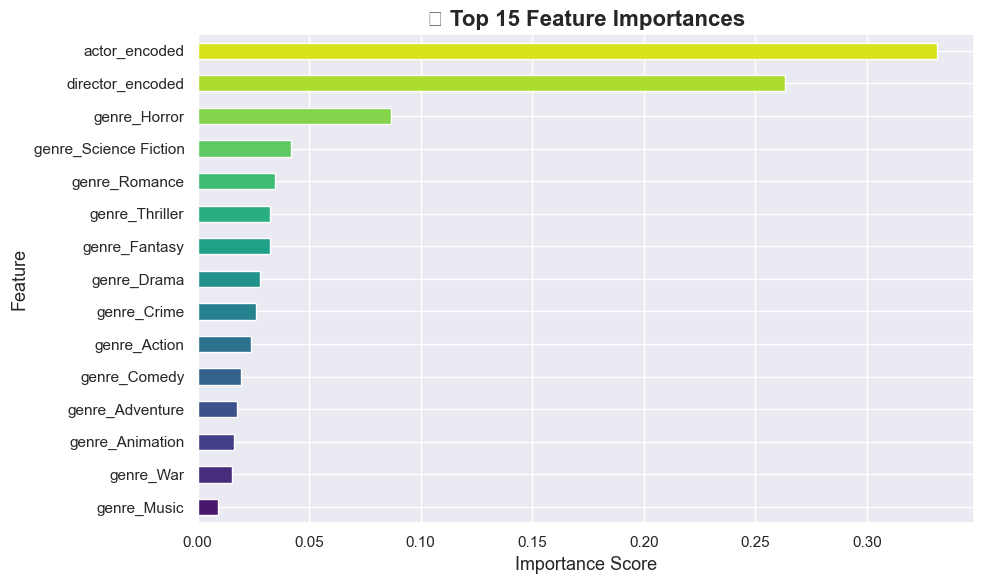

📁 Saved: feature_importance.png


In [12]:
# ── Feature Importance ──────────────────────────────────────────────
importances = pd.Series(model.feature_importances_, index=feature_cols)
top_features = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color=sns.color_palette("viridis", len(top_features)), ax=ax)
ax.set_title('🏆 Top 15 Feature Importances', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: feature_importance.png")

## 6. Visualizations

### 6a. Correlation Heatmap

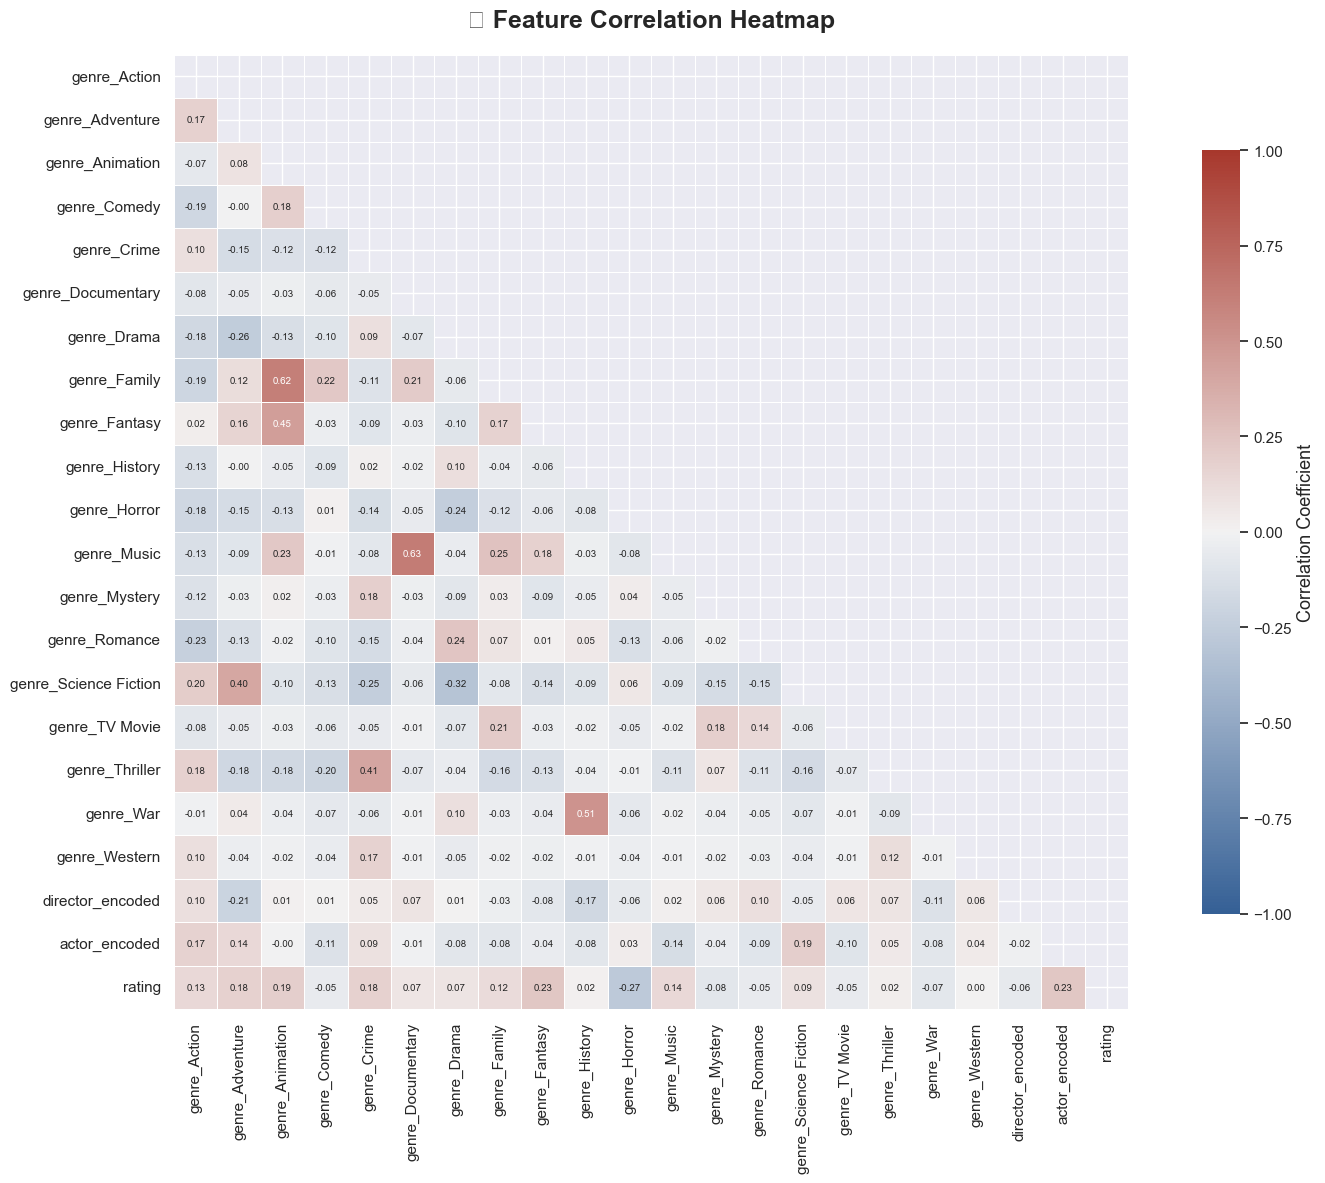

📁 Saved: correlation_heatmap.png


In [13]:
# ── Correlation Heatmap ─────────────────────────────────────────────
# Build correlation matrix of all numeric features + target
corr_df = pd.concat([X, y.rename('rating')], axis=1)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
    ax=ax
)
ax.set_title('🔥 Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: correlation_heatmap.png")

### 6b. Actual vs Predicted Ratings Distribution

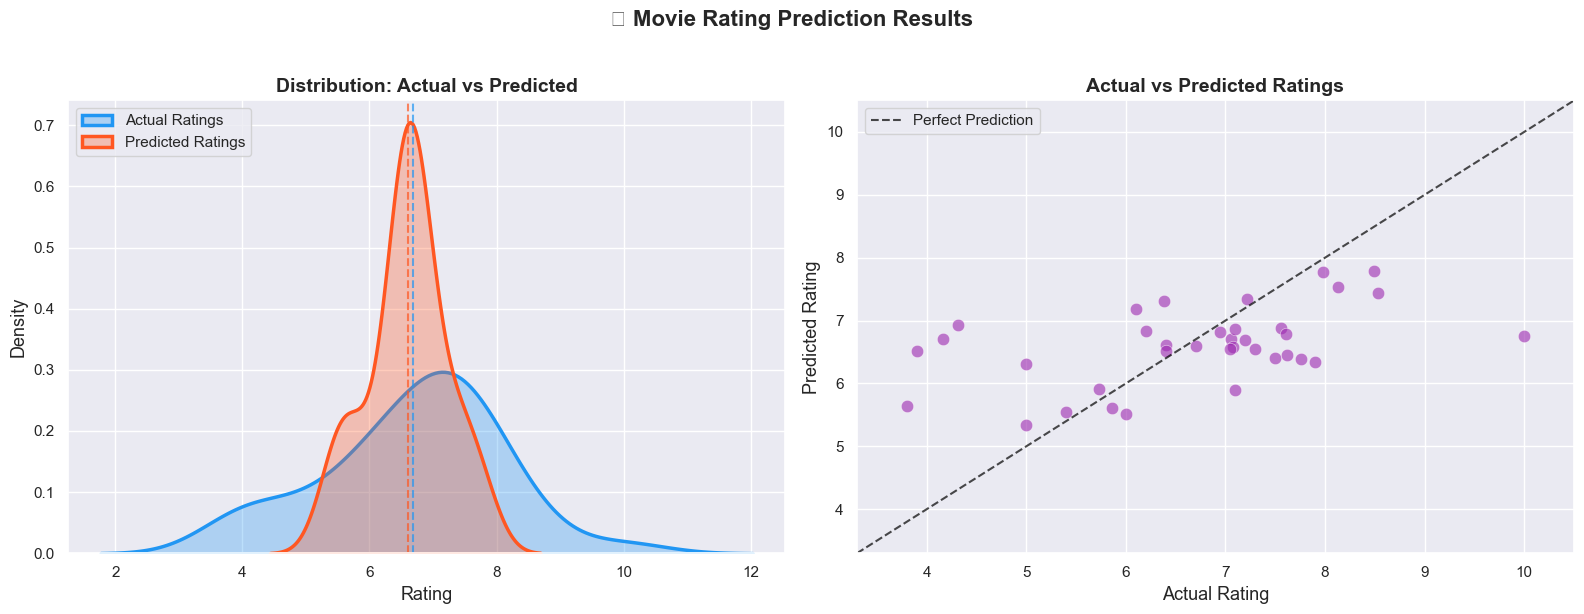

📁 Saved: actual_vs_predicted.png


In [14]:
# ── Actual vs Predicted Distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overlaid distributions
ax1 = axes[0]
sns.kdeplot(y_test, label='Actual Ratings', color='#2196F3', linewidth=2.5, fill=True, alpha=0.3, ax=ax1)
sns.kdeplot(y_pred, label='Predicted Ratings', color='#FF5722', linewidth=2.5, fill=True, alpha=0.3, ax=ax1)
ax1.set_title('Distribution: Actual vs Predicted', fontsize=14, fontweight='bold')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Density')
ax1.legend(fontsize=11, loc='upper left')
ax1.axvline(y_test.mean(), color='#2196F3', linestyle='--', alpha=0.7, label=f'Actual mean: {y_test.mean():.2f}')
ax1.axvline(np.mean(y_pred), color='#FF5722', linestyle='--', alpha=0.7, label=f'Predicted mean: {np.mean(y_pred):.2f}')

# Plot 2: Scatter plot — Actual vs Predicted
ax2 = axes[1]
ax2.scatter(y_test, y_pred, alpha=0.6, color='#9C27B0', edgecolors='white', s=80, linewidth=0.5)
min_val = min(y_test.min(), y_pred.min()) - 0.5
max_val = max(y_test.max(), y_pred.max()) + 0.5
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, alpha=0.7, label='Perfect Prediction')
ax2.set_title('Actual vs Predicted Ratings', fontsize=14, fontweight='bold')
ax2.set_xlabel('Actual Rating')
ax2.set_ylabel('Predicted Rating')
ax2.legend(fontsize=11)
ax2.set_xlim(min_val, max_val)
ax2.set_ylim(min_val, max_val)

plt.suptitle('🎬 Movie Rating Prediction Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved: actual_vs_predicted.png")

## 7. Summary

| Metric | Value |
|--------|-------|
| **Algorithm** | Random Forest Regressor (100 trees) |
| **Train/Test Split** | 80% / 20% |
| **Features** | Genre (one-hot) + Director (label) + Lead Actor (label) |
| **Target** | Movie Rating |

---
*Generated by CineMetric — Movie Rating Prediction System*